In [1]:
# Imports and constants


import matplotlib.pyplot as plt
import numpy as np
import h5py as h5
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
from scipy.stats import spearmanr
import eagle_tools
from statsmodels.nonparametric.smoothers_lowess import lowess
import xgboost as xgb
import shap
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import minmax_scale, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from scipy.stats import spearmanr , binned_statistic
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score
import seaborn as sns

# Use custom matplotlib template
plt.style.use('/users/arirrobe/MachineLearning/MBH-GalaxyHalo-SHAP/mnras_mpl.stylesheet')

cosmology = FlatLambdaCDM(H0=67.74, Om0=0.3089)

omega_b = 0.0482519
omega_0 = 0.307
omega_lambda = 0.693
Z_solar = 0.012663729
M_solar = 1.98841e33
eps_r = 0.1
eps_f = 0.15
c = 2.99792458e10
yr = 3.154e7
H_0 = 67.77
H_0_cgs = 3.2407789e-18
Mpc = 3.086e24 
kpc = 3.086e21
pc = 3.086e18
G = 6.67e-8
km = 1e5
h = 0.6777
boxsize = 67770/h
Z_w = 0.002
gamma_wz = 2
f_wz = 0.25
ebar_w = 3.6
N_SNII = 0.0118
rho_crit =  8.6e-30 #g/cm^3 given by 3H^2/8piG

cgs_conv_mass = 1.989e+43
cgs_conv_sfr = 6.304278922345484e+25
cgs_conv_birthdensity = 6.769911178294543e-31
cgs_conv_acc_rate = 6.445909132449984e+23
cgs_conv_vel = 100000
cgs_conv_radius = 3.085678e+21

dm_particlemass = 9.7e6*M_solar

data_load_path = '/users/arirrobe/MachineLearning/EAGLE_Datasets'
archive_data_path = '/mnt/cosmo_scratch/users/arijdavi/hpcdata0_backup/EAGLE_catalogues/L0100N1504/REFERENCE/028_z000p000'
save_path = '/users/arirrobe/MachineLearning/MBH-GalaxyHalo-SHAP/outputs'

In [4]:
with h5.File(f'{data_load_path}/L0100N1504_AllHaloProperties.h5', 'r') as fi:
    matched_group_nums = fi['/GroupNumber'][()].astype(np.int32)
    kappa_co = fi['kappa_co'][()]
    e_bind = fi['E_Bind'][()]
    m200 = fi['M200'][()]
fi.close()

with h5.File(f'{data_load_path}/L0100N1504_NewFeedback.h5', 'r') as fi:
    group_nums = fi['/GroupNumber'][()].astype(np.int64)
    m_bh = fi['/M_BH_INTERP/'][()][:,0]
fi.close()

with h5.File(f'{data_load_path}/L0100N1504_LinearProperties.h5', 'r') as fi:
    group_num_z0 = fi['GroupNumber'][()]
    ssfr = fi['sSFR'][()]
fi.close()

ssfr = ssfr[np.argsort(group_num_z0)]
group_num_z0 = group_num_z0[np.argsort(group_num_z0)]

idx_in_group_num_z0 = np.array([np.where(group_num_z0 == gn)[0][0] for gn in matched_group_nums])
ssfr = ssfr[idx_in_group_num_z0]

with h5.File(f'{data_load_path}/L0100N1504_MorphoKinem.h5', 'r') as fi:
    all_morpho_kinem = fi['AllMorphoKinem'][()]
    all_morpho_z = fi['AllMorphoKinem'][()][:,1]
    all_ellipticity = fi['AllMorphoKinem'][()][:,3]
    all_triaxiality = fi['AllMorphoKinem'][()][:,4]
fi.close()

with h5.File(f'{data_load_path}/L0100N1504_All_DiscToTotal.h5', 'r') as fi:
    all_disc_to_total = fi['All_DiscToTotal'][()]
fi.close()

with h5.File('/users/arirrobe/MachineLearning/EAGLE_Datasets/L0100N1504_Neighbours.h5', 'r') as fi:
    dnn = fi['NeighbourDistance'][()]/1e3
    mnn = fi['NeighbourMass'][()]
fi.close()

all_kappa = np.array(pd.read_csv(f'{data_load_path}/AllKappaInfo.csv', index_col=0, skiprows=0))

missing_idx = []
for i, gn in enumerate(matched_group_nums):
    if gn == 1:
        all_z = all_kappa[all_kappa[:,0] == gn, 1]
    
    galaxy = all_kappa[all_kappa[:,0] == gn]
    if galaxy.shape[0] <= 8:
        missing_idx.append(gn)

missing_idx = np.unique(missing_idx)
print(missing_idx)
print(len(missing_idx))

all_kappa = np.delete(all_kappa, np.argwhere(np.isin(all_kappa[:,0], missing_idx)), 0)
all_triaxiality = np.delete(all_triaxiality, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_ellipticity = np.delete(all_ellipticity, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_morpho_z = np.delete(all_morpho_z, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_morpho_kinem = np.delete(all_morpho_kinem, np.argwhere(np.isin(all_morpho_kinem[:,0], missing_idx)), 0)
all_disc_to_total = np.delete(all_disc_to_total, np.argwhere(np.isin(all_disc_to_total[:,0], missing_idx)), 0)
    
kappa_co = all_kappa[all_kappa[:,1]<= 0.001, 2]
triax_z0 = all_triaxiality[all_morpho_z <= 0.001]
ellip_z0 = all_ellipticity[all_morpho_z <= 0.001]
disc_to_total = all_disc_to_total[all_disc_to_total[:,1] <= 0.001, 2]

all_alpha_m = ((all_ellipticity**2) + 1 - all_triaxiality)/2
alpha_m = all_alpha_m[all_morpho_z <= 0.001]


idx_in_group_nums = np.array([np.where(group_nums == gn)[0][0] for gn in matched_group_nums])
m_bh = m_bh[idx_in_group_nums]


with h5.File(f'{archive_data_path}/concentrations.hdf5', 'r') as fi:
    halo_conc = fi['Concentration'][()]
    conc_gn = fi['GroupNumber'][()]
fi.close()

_, gn_idx, _ = np.intersect1d(conc_gn, matched_group_nums, return_indices=True)
halo_conc = halo_conc[gn_idx]

with h5.File(f'{archive_data_path}/DMO_binding_energies.hdf5', 'r') as fi:
    e_bind_2500 = fi['Particle_E_2500'][()]
    e_bind_500 = fi['Particle_E_500'][()]
    e_bind_200 = fi['Particle_E_200'][()]
    e_bind_gn = fi['GroupNumber'][()]
fi.close()


idx_in_ebind_gn = np.array([np.where(e_bind_gn == gn)[0][0] for gn in matched_group_nums])
e_bind_2500 = e_bind_2500[idx_in_ebind_gn]
e_bind_500 = e_bind_500[idx_in_ebind_gn]
e_bind_200 = e_bind_200[idx_in_ebind_gn]

with h5.File(f'{data_load_path}/L0100N1504_Mstar_MBH_Histories.h5', 'r') as fi:
    all_mstar_mbh = fi['Mstar_MBH_Arr'][()]
fi.close()

all_mstar_mbh = np.delete(all_mstar_mbh, np.argwhere(all_mstar_mbh[:,0]==0), 0)
all_mstar_mbh = all_mstar_mbh[np.lexsort((all_mstar_mbh[:,1], all_mstar_mbh[:,0]))]


all_mstar = np.delete(all_mstar_mbh, 2, 1)
all_mbh = all_mstar_mbh[:,:3]
all_mbh[all_mbh[:,1]<= 0.001, 2] = m_bh

all_mstar = np.delete(all_mstar, np.argwhere(np.isin(all_mstar[:,0], missing_idx)), 0)
all_mbh = np.delete(all_mbh, np.argwhere(np.isin(all_mbh[:,0], missing_idx)), 0)

m_star = all_mstar[all_mstar[:,1]<= 0.001, 2]
m_bh = all_mbh[all_mbh[:,1]<= 0.001, 2]



with h5.File(f'{data_load_path}/L0100N1504_M200_Histories.h5', 'r') as fi:
    all_m200 = fi['M200_Histories'][()]
fi.close()

all_m200[all_m200[:,1]<= 0.001, 2] = m200
all_m200 = np.delete(all_m200, np.argwhere(np.isin(all_m200[:,0], missing_idx)), 0)


m200 = np.log10(m200)
all_mstar[:,2] = np.log10(all_mstar[:,2])

all_mbh[:,2] = np.log10(all_mbh[:,2])
all_m200[:,2] = np.log10(all_m200[:,2])
m_star = np.log10(m_star)
m_bh = np.log10(m_bh)
e_bind = np.log10(np.abs(e_bind))
e_bind_2500 = np.log10(np.abs(e_bind_2500) * cgs_conv_mass*cgs_conv_vel / h)
e_bind_500 = np.log10(np.abs(e_bind_500) * cgs_conv_mass*cgs_conv_vel / h)
e_bind_200 = np.log10(np.abs(e_bind_200) * cgs_conv_mass*cgs_conv_vel / h)
mnn = np.log10(mnn)

missing_idx = np.argwhere(np.isin(matched_group_nums, missing_idx)).ravel()
matched_group_nums = np.delete(matched_group_nums, missing_idx)
m200 = np.delete(m200, missing_idx)
e_bind = np.delete(e_bind, missing_idx)
halo_conc = np.delete(halo_conc, missing_idx)
e_bind_2500 = np.delete(e_bind_2500, missing_idx)
e_bind_500 = np.delete(e_bind_500, missing_idx)
e_bind_200 = np.delete(e_bind_200, missing_idx)
ssfr = np.delete(ssfr, missing_idx)
dnn = np.delete(dnn, missing_idx)
mnn = np.delete(mnn, missing_idx)


quenched_idx = np.argwhere(ssfr < 1e-11).ravel()  # Quenched if sSFR <= 1e-11
sf_idx = np.argwhere(ssfr >= 1e-11).ravel()  # Star-forming if sSFR <= 1e-11

quenched_groupnums = matched_group_nums[quenched_idx]
sf_groupnums = matched_group_nums[sf_idx]

e_bind = e_bind_2500

quenched_idx_ebind = np.argwhere(ssfr[np.argsort(e_bind)] < 1e-11).ravel()  # Quenched if sSFR <= 1e-11
sf_idx_ebind = np.argwhere(ssfr[np.argsort(e_bind)] >= 1e-11).ravel()  # Star-forming if sSFR <= 1e-11


e_bind_sorted = e_bind[np.argsort(e_bind)]
m_star_ebind = m_star[np.argsort(e_bind)]
matched_group_nums_ebind = matched_group_nums[np.argsort(e_bind)]
m200_ebind = m200[np.argsort(e_bind)]
m_bh_ebind = m_bh[np.argsort(e_bind)]
kappa_co_ebind = kappa_co[np.argsort(e_bind)]
alpha_m_ebind = alpha_m[np.argsort(e_bind)]
disc_to_total_ebind = disc_to_total[np.argsort(e_bind)]
dnn_ebind = dnn[np.argsort(e_bind)]
mnn_ebind = mnn[np.argsort(e_bind)]

lowess_kappa_co_ebind = lowess(kappa_co, e_bind, return_sorted=True, frac=0.2, it=3)[:,1]
delta_kappa_co_ebind = kappa_co_ebind - lowess_kappa_co_ebind

lowess_m_bh_ebind = lowess(m_bh, e_bind, return_sorted=True, frac=0.2, it=3)[:,1]
delta_m_bh_ebind = m_bh_ebind - lowess_m_bh_ebind

lowess_m200_ebind = lowess(m200, e_bind, return_sorted=True, frac=0.2, it=3)[:,1]
delta_m200_ebind = m200_ebind - lowess_m200_ebind

lowess_alpha_m_ebind = lowess(alpha_m, e_bind, return_sorted=True, frac=0.2, it=3)[:,1]
delta_alpha_m_ebind = alpha_m_ebind - lowess_alpha_m_ebind

lowess_disc_to_total_ebind = lowess(disc_to_total, e_bind, return_sorted=True, frac=0.2, it=3)[:,1]
delta_disc_to_total_ebind = disc_to_total_ebind - lowess_disc_to_total_ebind

lowess_dnn_ebind = lowess(dnn, e_bind, return_sorted=True, frac=0.2, it=3)[:,1]
delta_dnn_ebind = dnn_ebind - lowess_dnn_ebind

lowess_mnn_ebind = lowess(mnn, e_bind, return_sorted=True, frac=0.2, it=3)[:,1]
delta_mnn_ebind = mnn_ebind - lowess_mnn_ebind

[ 643  741  799  970 1039 1280 1447 1760 1772 1851 2064 2080 2323 2521
 2566 2649 2656 2682 2780 2811 2854 2925 3016 3022 3143 3274 3356 3387
 3424 3469 3547 3615 3643 3702 3777 3952]
36


divide by zero encountered in log10


In [5]:
def spearman_track_ebind(c, y, x):
    # Define binning windows and empty metric lists    
    halo_total = len(y)
    delta_bin = 20 #200
    lower_bound = 0
    upper_bound = 500 #5000
    bin_means = []
    bins = []
    count = -1

    sr_arr = np.ones(5000)*np.nan
    p_arr = np.ones(5000)*np.nan


    # While the upper-bound of the bin edge is lower than the total number of haloes, continue walking bin process
    while upper_bound < halo_total:

        # Pull the correct values for the current bin range
        x_bin = x[lower_bound:upper_bound+delta_bin]
        c_bin = c[lower_bound:upper_bound+delta_bin]
        y_bin = y[lower_bound:upper_bound+delta_bin]

        # Record the x values at the edges of the bin, as well as the mean x value of the bin
        bins.append(np.min(x_bin))
        bins.append(np.max(x_bin))
        bin_means.append((np.min(x_bin)+np.max(x_bin))/2)
        
        # Calculate the Spearman coefficient and p-value for the bin for each input parameter
        sr_arr[count+1] = spearmanr(c_bin, y_bin)[0]
        p_arr[count+1] = spearmanr(c_bin, y_bin)[1]
        
        # Start reducing bin sixe at a given mass threshold
        if bin_means[count] > 58:
            delta_bin = int(halo_total/25)
            lower_bound = int(upper_bound - 1.25*delta_bin)
        else: 
            lower_bound += delta_bin
            
        upper_bound += delta_bin
        count += 1

    # Truncate arrays to remove empty space
    bins, bin_means = np.array(bins), np.array(bin_means)
    sr_arr = sr_arr[0:len(bin_means)]
    p_arr = p_arr[0:len(bin_means)]
    
    return bin_means, sr_arr, p_arr

In [24]:
y = m_bh
X = pd.DataFrame(data={
    # '$E_{\\rm bind}$': e_bind,
    '$\\kappa_{\\rm co}$': kappa_co,
    '$\\alpha_{\\rm m}$': alpha_m,
    'D/T': disc_to_total,
    '$D_{\\rm NN}$': dnn,
    '$M_{\\rm NN}$': mnn,
})

# gal_mask = (e_bind >= 58) & (e_bind <= 58.5)

# y = y[gal_mask]
# X = X[gal_mask]

indices = np.arange(0, len(y), 1)
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(X, y, indices, test_size=0.5, shuffle=True, random_state=42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

scaler = MinMaxScaler((0,1))
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

(1687, 5) (1687,) (1687, 5) (1687,)


[0]	validation_0-rmse:4.48016	validation_1-rmse:4.50192
[10]	validation_0-rmse:0.42508	validation_1-rmse:0.52322
[20]	validation_0-rmse:0.34468	validation_1-rmse:0.50967
[24]	validation_0-rmse:0.33130	validation_1-rmse:0.51118


MSE: 0.150
RMSE: 0.388
MAE: 0.300
R^2: 0.777


MSE: 0.257
RMSE: 0.507
MAE: 0.399
R^2: 0.610


(1687, 5, 5)
[[ 0.0505427  -0.00774369  0.02601886 -0.01264404 -0.00549081]
 [-0.00774368 -0.00644228 -0.02078021  0.0260297  -0.00518234]
 [ 0.02601886 -0.02078021 -0.02861877 -0.00127677 -0.0021575 ]
 [-0.01264402  0.02602973 -0.00127677 -0.22517271 -0.00573575]
 [-0.0054908  -0.00518233 -0.0021575  -0.00573573  0.03526931]]
(1687, 5)


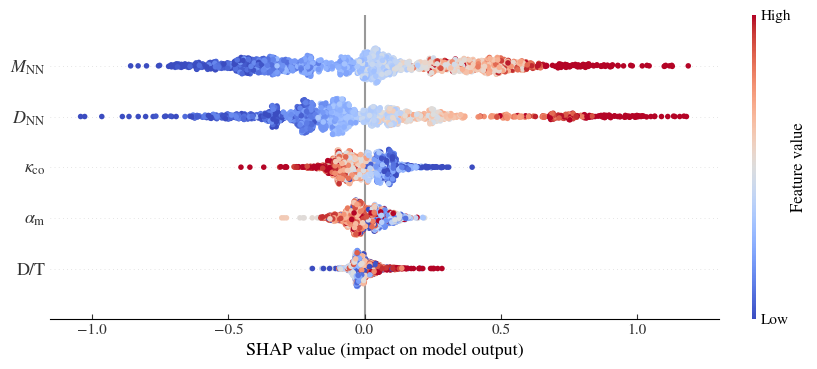

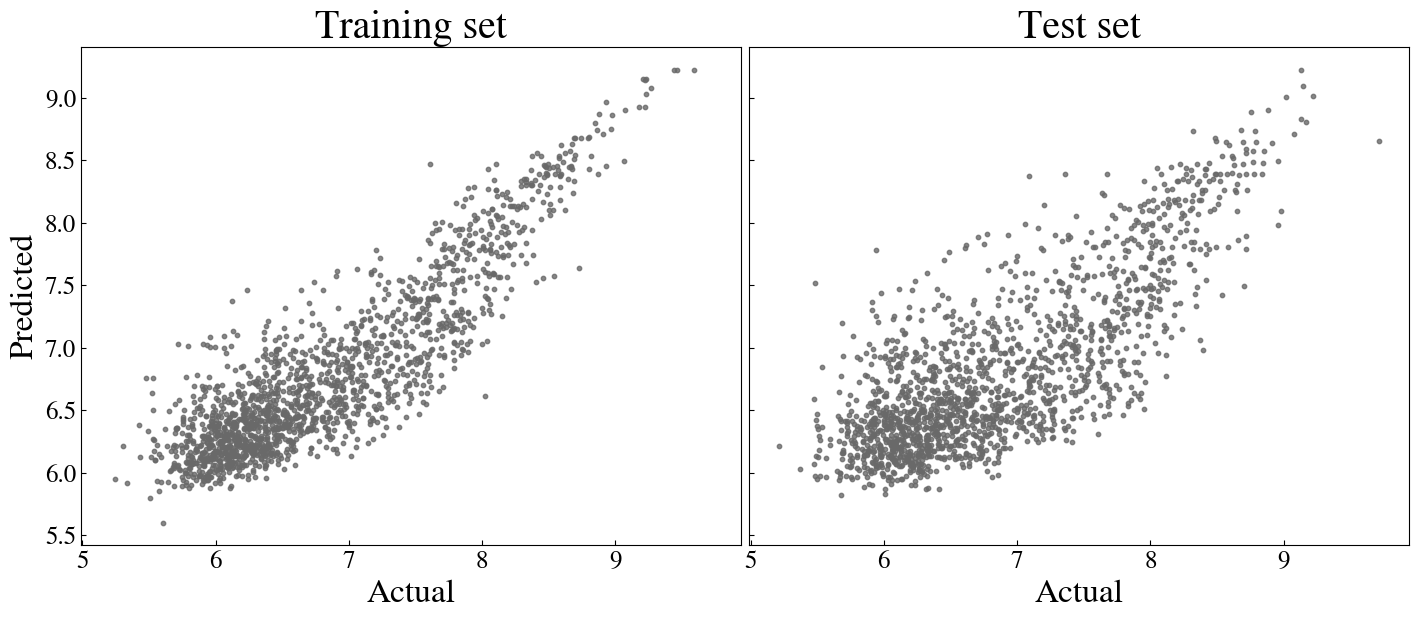

In [25]:
xgb_model = xgb.XGBRegressor(n_estimators=100, early_stopping_rounds=10)
xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_train_scaled,y_train), (X_test_scaled, y_test)], verbose=10)

yhat = xgb_model.predict(X_train_scaled)
mse = mean_squared_error(y_train, yhat)
rmse = mean_squared_error(y_train, yhat, squared=False)
mae = mean_absolute_error(y_train, yhat)
r_squared = r2_score(y_train, yhat)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R^2: {r_squared:.3f}")
print("\n")


yhat_test = xgb_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, yhat_test)
rmse = mean_squared_error(y_test, yhat_test, squared=False)
mae = mean_absolute_error(y_test, yhat_test)
r_squared = r2_score(y_test, yhat_test)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R^2: {r_squared:.3f}")
print("\n")

explainer = shap.TreeExplainer(xgb_model, feature_perturbation='tree_path_dependent')
shap_values = explainer(X_test_scaled)
shap_interaction = explainer.shap_interaction_values(X_test_scaled)

# feature_ranges = np.percentile(np.abs(shap_values.values), 99, axis=0)
# feature_ranges[feature_ranges == 0] = 1e-12 
# scaled_shap = shap_values.values / feature_ranges
# scaled_shap = shap.Explanation(values=scaled_shap, base_values=shap_values.base_values, data=shap_values.data, feature_names=shap_values.feature_names)
# shap.plots.beeswarm(scaled_shap, color=plt.get_cmap("coolwarm"), show=False)


shap.plots.beeswarm(shap_values, color=plt.get_cmap("coolwarm"), show=False)

fig, ax = plt.subplots(1,2, figsize=(14,6), sharex=True, sharey=True, layout='compressed')
ax[0].scatter(y_train, yhat, c='dimgrey', s=10, alpha=0.8)
ax[1].scatter(y_test, yhat_test, c='dimgrey', s=10, alpha=0.8)
ax[0].set_xlabel('Actual')
ax[0].set_ylabel('Predicted')
ax[1].set_xlabel('Actual')
ax[0].set_title('Training set')
ax[1].set_title('Test set')

# shap.dependence_plot('$\\kappa_{\\rm co}$', shap_values.values, X_test_scaled, feature_names=X_test_scaled.columns, interaction_index='$E_{\\rm bind}$')
# shap.dependence_plot('T', shap_values.values, X_test_scaled, feature_names=X_test_scaled.columns, interaction_index='$E_{\\rm bind}$')
# shap.dependence_plot('$\\epsilon$', shap_values.values, X_test_scaled, feature_names=X_test_scaled.columns, interaction_index='$E_{\\rm bind}$')

print(shap_interaction.shape)
print(shap_interaction[0])
print(shap_values.shape)


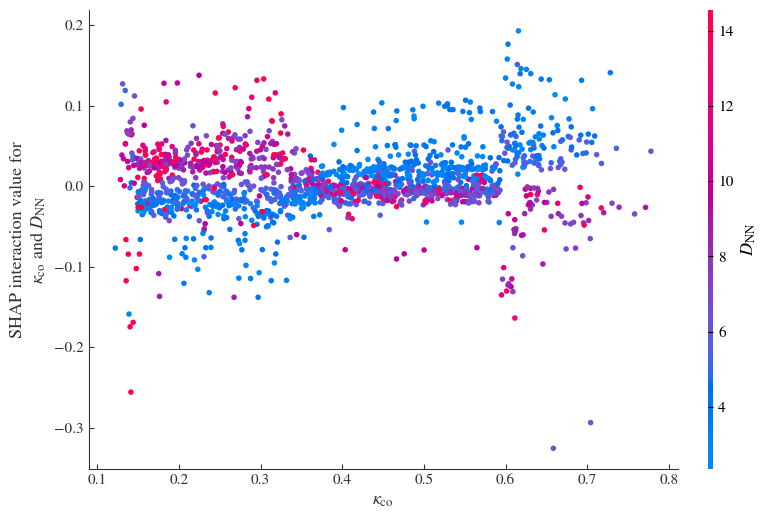

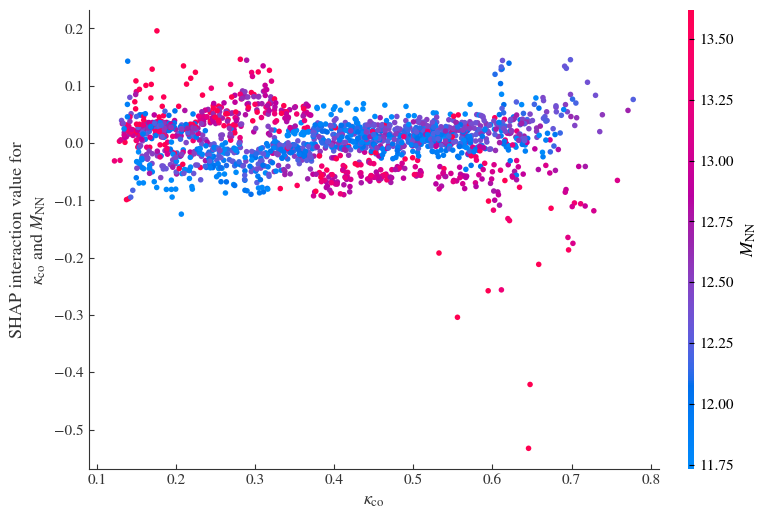

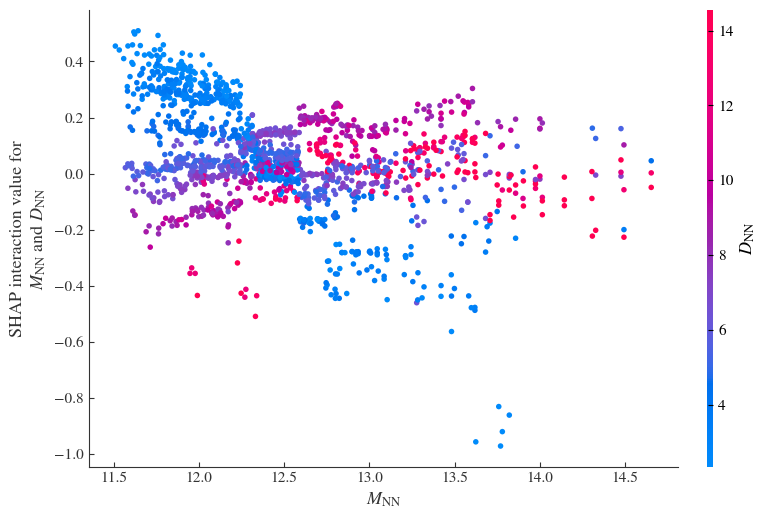

(1687, 5, 5)


In [28]:
shap.dependence_plot(('$\\kappa_{\\rm co}$', '$D_{\\rm NN}$'), shap_interaction, X_test, display_features=X_test)
shap.dependence_plot(('$\\kappa_{\\rm co}$', '$M_{\\rm NN}$'), shap_interaction, X_test, display_features=X_test)
shap.dependence_plot(('$M_{\\rm NN}$', '$D_{\\rm NN}$'), shap_interaction, X_test, display_features=X_test)

print(shap_interaction.shape)


# fig, ax = plt.subplots(figsize=(10,6), sharex=True, sharey=True, layout='compressed')
# ax.scatter(shap_interaction[:,1,0], , c=X_test['$E_{\\rm bind}$'], s=10, cmap='rainbow', alpha=0.8)
# cb = fig.colorbar(ax.collections[0], ax=ax, location='top', shrink=0.9)
# cb.set_label('SHAP Interaction Values for $\\kappa_{\\rm co}$ vs $\\alpha_{\\rm m}$')
# ax.set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')
# ax.set_ylabel('${\\rm log_{10}}M_{\\rm BH}$ [$M_{\\odot}$]')

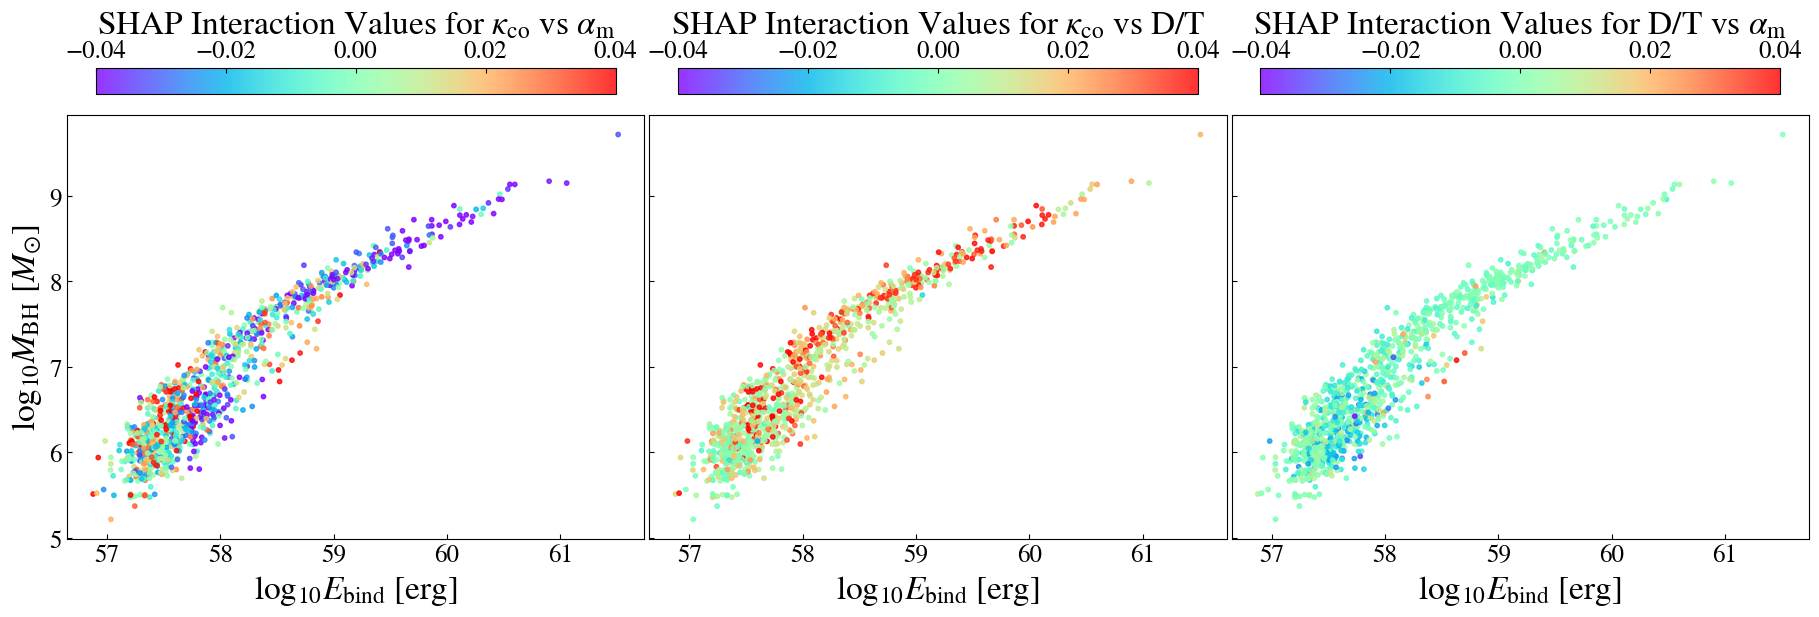

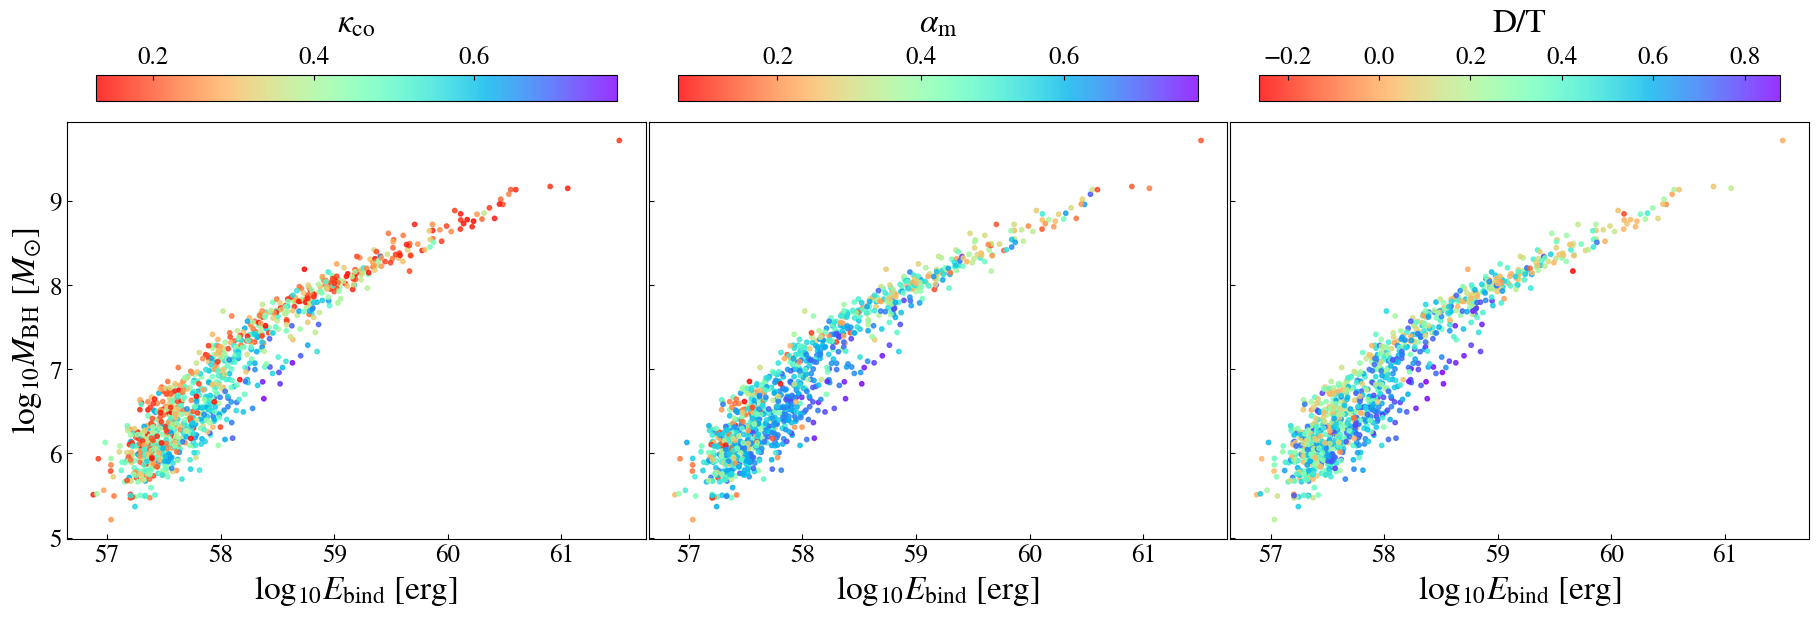

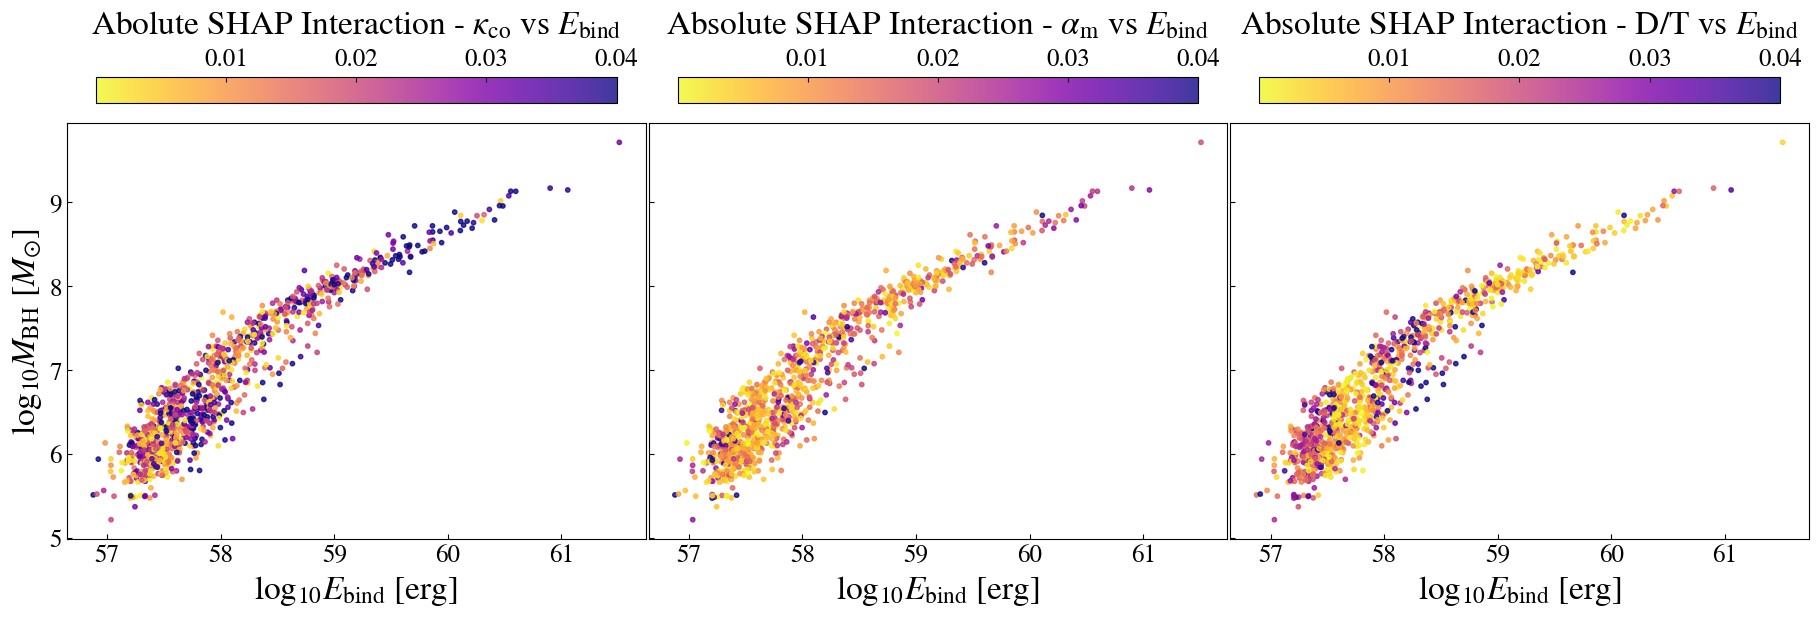

In [35]:
fig, ax = plt.subplots(1,3, figsize=(18,6), sharex=True, sharey=True, layout='compressed')
ax[0].scatter(X_test['$E_{\\rm bind}$'], y_test, c=shap_interaction[:,1,0], s=10, cmap='rainbow', alpha=0.8, vmin=-0.04, vmax=0.04)
cb = fig.colorbar(ax[0].collections[0], ax=ax[0], location='top', shrink=0.9)
cb.set_label('SHAP Interaction Values for $\\kappa_{\\rm co}$ vs $\\alpha_{\\rm m}$')
ax[0].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')
ax[0].set_ylabel('${\\rm log_{10}}M_{\\rm BH}$ [$M_{\\odot}$]')

ax[1].scatter(X_test['$E_{\\rm bind}$'], y_test, c=shap_interaction[:,1,3], s=10, cmap='rainbow', alpha=0.8, vmin=-0.04, vmax=0.04)
cb = fig.colorbar(ax[1].collections[0], ax=ax[1], location='top', shrink=0.9)
cb.set_label('SHAP Interaction Values for $\\kappa_{\\rm co}$ vs D/T')
ax[1].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')

ax[2].scatter(X_test['$E_{\\rm bind}$'], y_test, c=shap_interaction[:,3,2], s=10, cmap='rainbow', alpha=0.8, vmin=-0.04, vmax=0.04)
cb = fig.colorbar(ax[2].collections[0], ax=ax[2], location='top', shrink=0.9)
cb.set_label('SHAP Interaction Values for D/T vs $\\alpha_{\\rm m}$')
ax[2].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')

plt.show()


fig, ax = plt.subplots(1,3, figsize=(18,6), sharex=True, sharey=True, layout='compressed')
ax[0].scatter(X_test['$E_{\\rm bind}$'], y_test, c=X_test['$\\kappa_{\\rm co}$'], s=10, cmap='rainbow_r', alpha=0.8)
cb = fig.colorbar(ax[0].collections[0], ax=ax[0], location='top', shrink=0.9)
cb.set_label('$\\kappa_{\\rm co}$', labelpad=10)
ax[0].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')
ax[0].set_ylabel('${\\rm log_{10}}M_{\\rm BH}$ [$M_{\\odot}$]')

ax[1].scatter(X_test['$E_{\\rm bind}$'], y_test, c=X_test['$\\alpha_{\\rm m}$'], s=10, cmap='rainbow_r', alpha=0.8)
cb = fig.colorbar(ax[1].collections[0], ax=ax[1], location='top', shrink=0.9)
cb.set_label('$\\alpha_{\\rm m}$', labelpad=10)
ax[1].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')

ax[2].scatter(X_test['$E_{\\rm bind}$'], y_test, c=X_test['D/T'], s=10, cmap='rainbow_r', alpha=0.8)
cb = fig.colorbar(ax[2].collections[0], ax=ax[2], location='top', shrink=0.9)
cb.set_label('D/T', labelpad=10)
ax[2].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')

plt.show()


fig, ax = plt.subplots(1,3, figsize=(18,6), sharex=True, sharey=True, layout='compressed')
ax[0].scatter(X_test['$E_{\\rm bind}$'], y_test, c=np.abs(shap_interaction[:,1,0]), s=10, cmap='plasma_r', alpha=0.8, vmax=0.04)
cb = fig.colorbar(ax[0].collections[0], ax=ax[0], location='top', shrink=0.9)
cb.set_label('Abolute SHAP Interaction - $\\kappa_{\\rm co}$ vs $E_{\\rm bind}$', labelpad=10)
ax[0].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')
ax[0].set_ylabel('${\\rm log_{10}}M_{\\rm BH}$ [$M_{\\odot}$]')

ax[1].scatter(X_test['$E_{\\rm bind}$'], y_test, c=np.abs(shap_interaction[:,2,0]), s=10, cmap='plasma_r', alpha=0.8, vmax=0.04)
cb = fig.colorbar(ax[1].collections[0], ax=ax[1], location='top', shrink=0.9)
cb.set_label('Absolute SHAP Interaction - $\\alpha_{\\rm m}$ vs $E_{\\rm bind}$', labelpad=10)
ax[1].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')

ax[2].scatter(X_test['$E_{\\rm bind}$'], y_test, c=np.abs(shap_interaction[:,3,0]), s=10, cmap='plasma_r', alpha=0.8, vmax=0.04)
cb = fig.colorbar(ax[2].collections[0], ax=ax[2], location='top', shrink=0.9)
cb.set_label('Absolute SHAP Interaction - D/T vs $E_{\\rm bind}$', labelpad=10)
ax[2].set_xlabel('${\\rm log_{10}}E_{\\rm bind}$ [erg]')

plt.show()
